#### Sampling with DBM (W1)
---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import sampler, densities, helpers
import itertools
from IPython.display import clear_output

# Avoid messy output for Euler method.
import warnings
warnings.filterwarnings('ignore', category = RuntimeWarning)

importlib.reload(sampler); importlib.reload(densities); importlib.reload(helpers);
sampler.hello()

Hello from the sampler file!


In [2]:
# NOTE Tweak as wanted.
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    # Computer Modern Roman
    "font.serif": ["cmr10"], 
    "mathtext.fontset": "cm",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 11,
    
    "figure.figsize": (4, 3), 
    "figure.dpi": 150,
    
    "lines.linewidth": 1.5,
    "lines.markersize": 4,
    "axes.linewidth": 0.8,
    "axes.formatter.use_mathtext": True
})

---
---
---

1. Convergence of $N$-densities to the true equilibrium density $\rho(x)$.
See Li and Menon.

Compare quad-quartic ($x^2/2 + x^4/4$) and pure quartic ($x^4/4$) for $N = 6$ and $N = 30$ respectively. Files: `densities.py`.

In [ ]:
# CALCULATE limiting and N-distributions.
importlib.reload(densities);
param_choices = [(6, "quad-quartic"), (30, "quad-quartic"), (6, "quartic"), (30, "quartic")]
# param_choices = [(6, "quadratic"), (30, "quadratic")]
grid = np.linspace(-2.5, 2.5, 500) 
K_Ns = []
rhos = []

def get_potential(type):
    if (type == "quad-quartic"):
        return lambda x: x**2/2 + x**4/4
    elif (type == "quartic"):
        return lambda x: x**4/4
    elif (type == "quadratic"):
        return lambda x: x**2/2
    else:
        raise ValueError(f"Potential {type} not found.")
    
for k, choices in enumerate(param_choices):
    N, pot_type = choices
    potential = get_potential(pot_type)

    # Same process as in paper, uses GS construction.
    pis, c_sqrs = densities.orthogonal_polys(N, potential, grid)
    K_N = densities.construct_kernel(N, potential, grid, pis, c_sqrs)

    q = 1 if ("quad" in pot_type) else 0
    g = 0 if (pot_type == "quadratic") else 1
    rho = densities.theoretical_density(grid, q = q, g = g)

    K_Ns.append(np.diag(K_N) / N) # Moved from the plotting part.
    rhos.append(rho)

In [ ]:
# PLOT limiting against N-distributions.
plot_names = ["A", "B", "C", "D"]
# plot_names = ["semicircle-A", "semicircle-B"]
for (K_N, rho, name) in zip(K_Ns, rhos, plot_names):
    # Clip grid to [-1.5, 1.5] to matchb resolution on paper.
    clip_range = 1.5 # Change if using semicircle.
    clipped_range = np.abs(grid) <= clip_range
    grid_clipped = grid[clipped_range]
    K_N_clipped = K_N[clipped_range]
    rho_clipped = rho[clipped_range]

    fig, ax = plt.subplots()
    ax.plot(grid_clipped, K_N_clipped, "b-", linewidth = 1.5, label = rf"Density $K_N(x)$.")
    ax.plot(grid_clipped, rho_clipped, "r--", linewidth = 1.5, label = rf"Limiting density $\rho(x)$.")

    # ax.set_title(rf"Convergence of $K_N(x)$ to $\rho(x)$: $N = $ {N}.")
    ax.set_xlabel('$x$');
    ax.set_ylabel('Density')
    ax.grid(True, alpha = 0.3)
    ax.set_xlim(-1*clip_range - 0.25, clip_range + 0.25)
    # ax.legend(loc = "best")

    plt.tight_layout()
    plt.show()
    # plt.savefig(f"figures/density-plot-{name}.pdf", bbox_inches = "tight", dpi = 100, format = "pdf")
    plt.close()

---

EXAMPLE PLOTS: Long-run sampling for large $N$ ($N = 500$ and $N = 1000$).

In [75]:
saved_data = np.load("data/long-simulations.npz")
results = saved_data["n500t10"][0]; results2 = saved_data["n1000t5"][0]

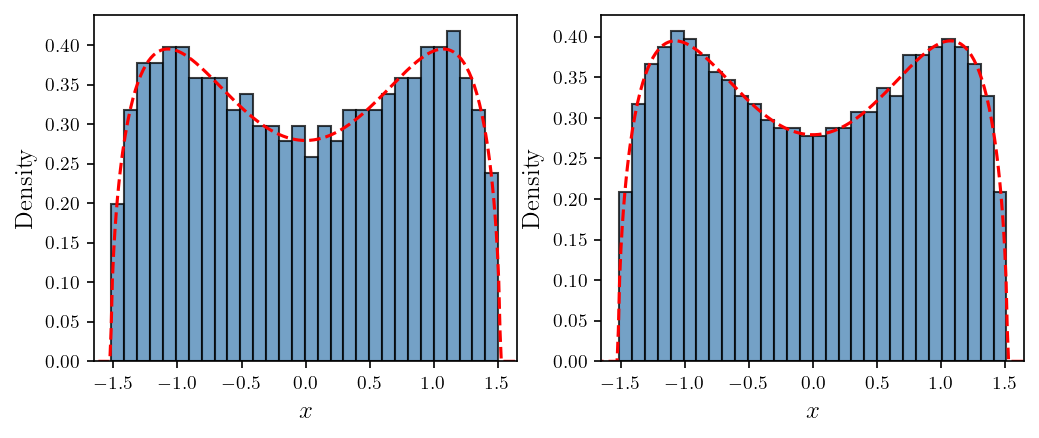

In [76]:
s_vals = np.linspace(-2.5, 2.5, 500)
density = densities.theoretical_density(s_vals, q = 0, g = 1)
fig1, axes = plt.subplots(1, 2, figsize = (8, 3))
ax1, ax2 = axes

ax1.hist(results, bins = 30, density = True, color = "steelblue", edgecolor = "black", alpha = 0.75)
ax1.plot(s_vals, density, 'r--')

# fig2, ax2 = plt.subplots()
ax2.hist(results2, bins = 30, density = True, color = "steelblue", edgecolor = "black", alpha = 0.75)
ax2.plot(s_vals, density, "r--")

for ax in [ax1, ax2]:
    ax.set_xlim(-1.65, 1.65)
    ax.set_ylabel("Density")
    ax.set_xlabel(r"$x$")

# fig1.savefig("figures/implicit-long-run-hists-N500.pdf", bbox_inches = "tight", dpi = 100, format = "pdf")
# fig2.savefig("figures/implicit-long-run-hists-N1000.pdf", bbox_inches = "tight", dpi = 100, format = "pdf")

plt.show()

---
---
---

08/06: investigation into the bias and Monte Carlo error of each method (mainly focusing on tamed and implicit schemes).

10/06: re-run now with Wasserstein distance (pass `distance_types = ["ks", "wasserstein"]` into the sampler and rearrange dictionary as appropriate.)
Run now for $T = 8.0$. For bias use $M = 50$ for $N = 20, 50$. For MC error use $N = 20, 50$ and just look at the implicit method, use $dt = 1/N$  to minimise bias. Plot traces of errors but also plot average of long-time (e.g. avg of $T = 5.0, 5.5, 6.0, ...$) errors with $\Delta t$ and $M$ depending on experiment.

It may be needed to increase $M$ for the bias investigation. 

In [41]:
# 1. BIAS. See above MD discussion.
T = 8.0; M = 50; N_ranges = [20, 50];
k_range = np.array(range(3, 5 + 1)) # 2**-k, note 2**-13 is < 1/(50**2).
methods = ["euler", "tamed", "implicit"]
distance_types = ["ks", "wasserstein"]
bias_results = {} # will need to recast for saving as npz.

for k, N, method in itertools.product(k_range, N_ranges, methods):
    clear_output(wait = True)
    print(rf"Running {method} method for N = {N}, step $2^({-1*k})$.")
    dt = 2.0**(-1*k)
    particles, times, distances = sampler.stochastic_sampler(N = N, T = T, dt = dt, num_trials = M, potential = "quartic", 
                           method = method, track_distance = True, distance_types = distance_types)
    
    ks_times = times[0]; ks_distances = distances[0];
    wass_times = times[1]; wass_distances = distances[1];
    
    bias_results[(N, k, method)] = {"ks_times": ks_times, "ks_distances": ks_distances, 
                                    "wass_times": wass_times, "wass_distances": wass_distances, 
                                    "particles": particles}

# RUN AND THEN SAVE RESULTS (next cell).

Running implicit method for N = 50, step $2^(-5)$.


In [42]:
# 2. SAVE BIAS.
npz_payload = {}
for (N, k, method), data in bias_results.items():
    prefix = f"N{N}-k{k}-{method}"
    npz_payload[f"{prefix}_ks_times"] = data["ks_times"]
    npz_payload[f"{prefix}_ks_distances"] = data["ks_distances"]
    npz_payload[f"{prefix}_wass_times"] = data["wass_times"]
    npz_payload[f"{prefix}_wass_distances"] = data["wass_distances"]
    npz_payload[f"{prefix}_particles"] = data["particles"]
    npz_payload["N"] = N_ranges; npz_payload["M"] = M; npz_payload["T"] = T;
    npz_payload["k_range"] = k_range; npz_payload["methods"] = methods;
    
np.savez_compressed("data/wass-bias-investigation-2.npz", **npz_payload)

In [68]:
# 3. RELOAD SAVED.
data_loaded = np.load("data/wass-bias-investigation-2.npz")
N_ranges = data_loaded["N"]; k_range = data_loaded["k_range"]; methods = data_loaded["methods"];
M = data_loaded["M"]; T = data_loaded["T"]

bias_results = {}
final_distances = {(N, method): {"k": [], "ks_final": [], "wass_final": []} for N, method in itertools.product(N_ranges, methods)}

for N, k, method in itertools.product(N_ranges, k_range, methods):
            prefix = f"N{N}-k{k}-{method}"

            if f"{prefix}_ks_times" in data_loaded:
                ks_distances = data_loaded[f"{prefix}_ks_distances"]
                wass_distances = data_loaded[f"{prefix}_wass_distances"]
                
                final_distances[(N, method)]["k"].append(k)
                final_distances[(N, method)]["ks_final"].append(ks_distances[-1])
                final_distances[(N, method)]["wass_final"].append(wass_distances[-1])

                bias_results[(N, k, method)] = {
                    "ks_times": data_loaded[f"{prefix}_ks_times"],
                    "ks_distances": ks_distances,
                    "wass_times": data_loaded[f"{prefix}_wass_times"],
                    "wass_distances": wass_distances,
                    "ks_final": ks_distances[-1], # NOTE Can change to be an avg over last T=1?
                    "wass_final": wass_distances[-1], # NOTE Same.
                    "particles": data_loaded[f"{prefix}_particles"]
                }
            else:
                raise ValueError(f"Did not find key {prefix}_ks_times.")
            
print(f"Loaded saved data.")

Loaded saved data.


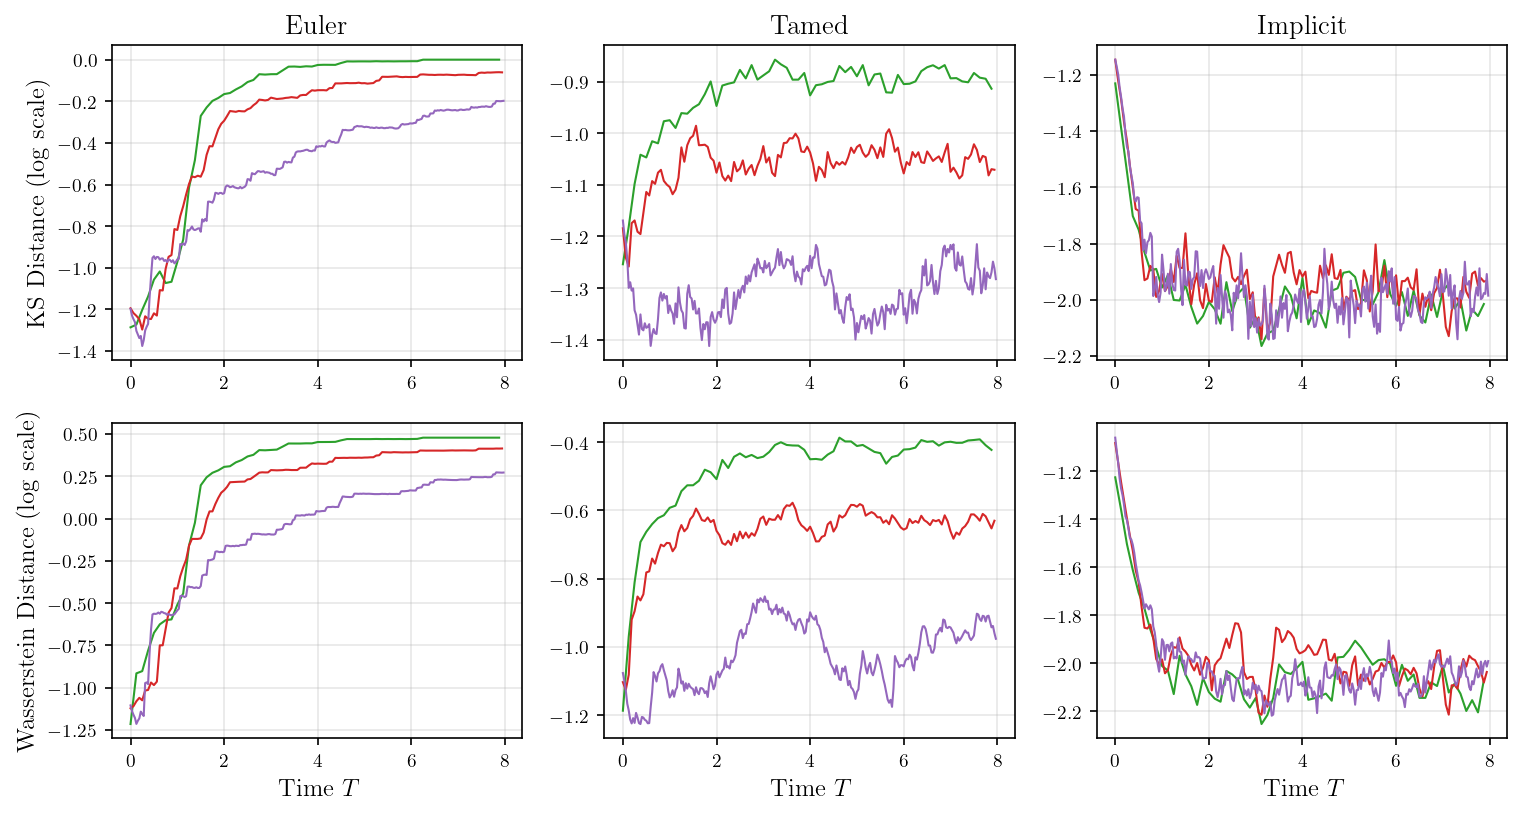

In [44]:
# 4a. BIAS PLOTTER.
dt_colours = list(plt.cm.tab10.colors) + list(plt.cm.Dark2.colors)
fixed_N1 = N_ranges[0]
fig, axes2d = plt.subplots(2, 3, figsize = (12, 6))
axes1d = axes2d.flatten()
axes1 = axes1d[0:3]; axes2 = axes1d[3:]

# First figure: only N1 (N = 20). Axes 1 for KS, then for Wasserstein.
for ax1, ax2, method in zip(axes1, axes2, methods):
    for k in k_range:
        key = (fixed_N1, k, method)
        data = bias_results[key]
        ax1.plot(data["ks_times"], np.log10(data["ks_distances"]), label = f"k = {k}", color = dt_colours[k - 1], lw = 1) 
        ax2.plot(data["wass_times"], np.log10(data["wass_distances"]), label = f"k = {k}", color = dt_colours[k - 1], lw = 1)

    ax1.set_title(method.capitalize())
    ax2.set_xlabel("Time $T$")

for ax in axes1d:
    ax.grid(True, alpha = 0.3)

axes1d[0].set_ylabel("KS Distance (log scale)")
axes1d[3].set_ylabel("Wasserstein Distance (log scale)")

plt.show()

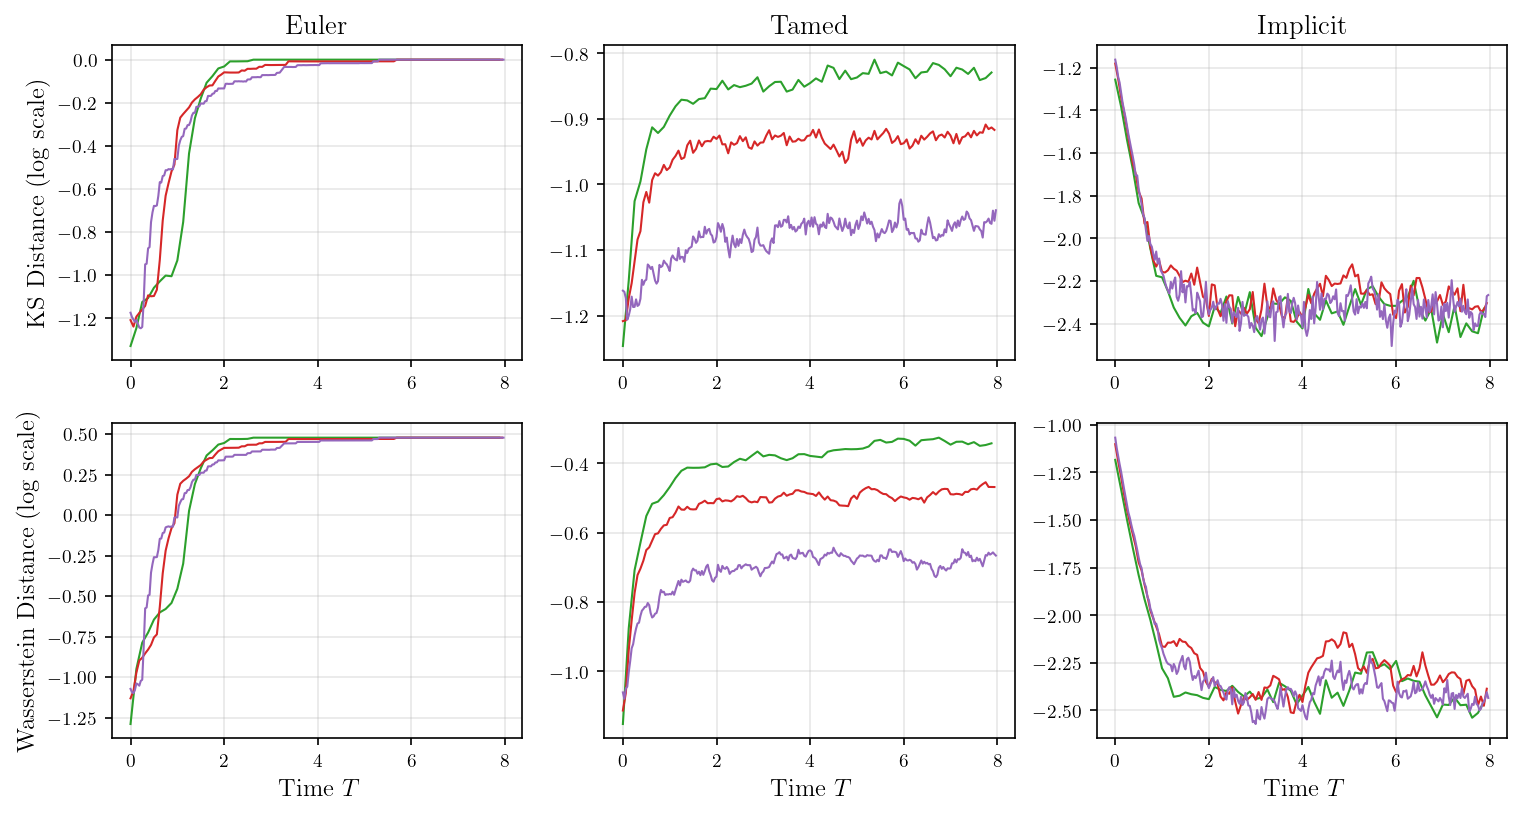

In [45]:
# 4b. BIAS PLOTTER (N = 50).
dt_colours = list(plt.cm.tab10.colors) + list(plt.cm.Dark2.colors)
fixed_N2 = N_ranges[1]
fig, axes2d = plt.subplots(2, 3, figsize = (12, 6))
axes1d = axes2d.flatten()
axes1 = axes1d[0:3]; axes2 = axes1d[3:]

# First figure: only N1 (N = 20). Axes 1 for KS, then for Wasserstein.
for ax1, ax2, method in zip(axes1, axes2, methods):
    for k in k_range:
        key = (fixed_N2, k, method)
        data = bias_results[key]
        ax1.plot(data["ks_times"], np.log10(data["ks_distances"]), label = f"k = {k}", color = dt_colours[k - 1], lw = 1) 
        ax2.plot(data["wass_times"], np.log10(data["wass_distances"]), label = f"k = {k}", color = dt_colours[k - 1], lw = 1)

    ax1.set_title(method.capitalize())
    ax2.set_xlabel("Time $T$")

for ax in axes1d:
    ax.grid(True, alpha = 0.3)

axes1d[0].set_ylabel("KS Distance (log scale)")
axes1d[3].set_ylabel("Wasserstein Distance (log scale)")

plt.show()

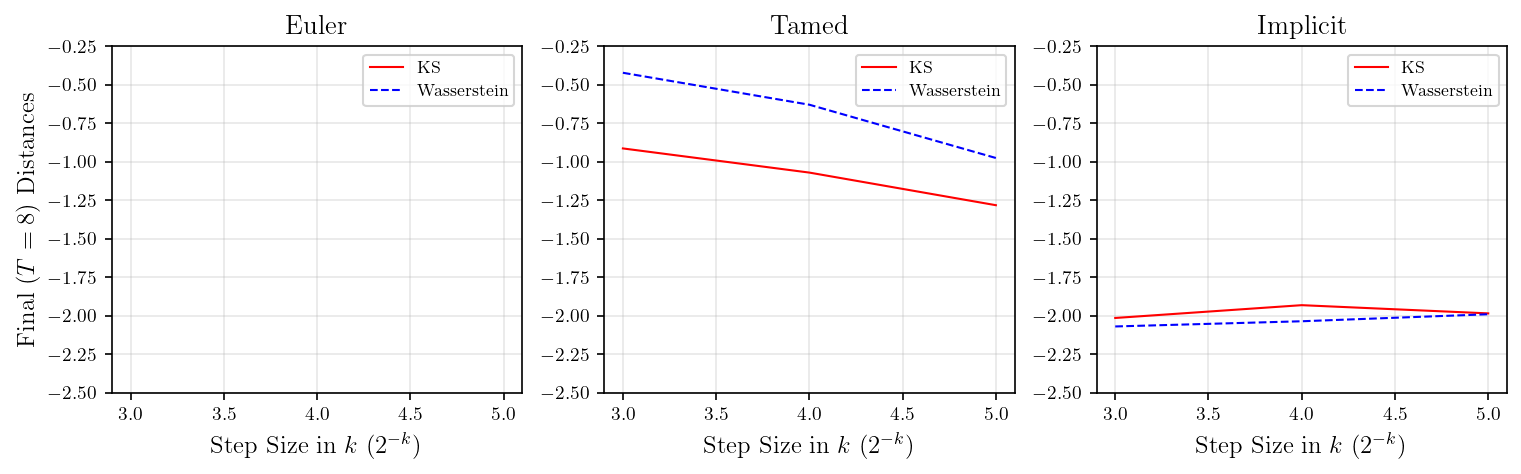

In [74]:
# 4c. BIAS PLOTTER (average of final times only).
# First row KS distances, second row Wasserstein, same as before: two figures for Ns.
fig, axes = plt.subplots(1, 3, figsize = (12, 3))

# First figure: only N1 (N = 20). Axes 1 for KS, then for Wasserstein.
for ax, method in zip(axes, methods):
    data = final_distances[(fixed_N1, method)]
    ax.plot(data["k"], np.log10(data["ks_final"]), label = "KS", color = "red", linestyle = "-", lw = 1)
    ax.plot(data["k"], np.log10(data["wass_final"]), label = "Wasserstein", color = "blue", linestyle = "--", lw = 1)

    ax.legend(loc = "best", fontsize = 8)
    ax.grid(True, alpha = 0.3)
    ax.set_xlabel("Step Size in $k$ ($2^{-k}$)")
    ax.set_ylim(-2.5, -0.25)
    ax.set_title(method.capitalize())

ax1, ax2, ax3 = axes
ax1.set_ylabel("Final ($T = 8$) Distances")

plt.show()

---
---
---
---
---

Implicit Monte Carlo investigation: fix $\Delta t = \mathcal{O}(1)$ and $\Delta t = \mathcal{O}(N)$ for two different experiments. Fix $N = 20$ and vary $M = 1000k$..

In [ ]:
T = 5.0; N = 30;
# M_range = np.concatenate(([100, 200, 500], [1000*k for k in range(1, 5 + 1)]))
M_range = [100, 200, 300, 400, 500, 1000, 2000, 3000, 4000, 5000, 10000]
dt_choices = ["OrootN"]
methods = ["implicit"]
mc_error_results = {}

for M, dt_choice, method in itertools.product(M_range, dt_choices, methods):
    clear_output(wait = True)
    match dt_choice:
        case "O1":
            dt = 0.5
        case "OrootN":
            dt = 1/np.sqrt(N)
        case "ON":
            dt = 1/N
        case "ON2":
            dt = 1/(N**2)

    print(rf"Running {method} method for M = {M} at step choice {dt_choice} = {dt}.")

    particles, times, distances = sampler.stochastic_sampler(N = N, T = T, dt = dt, num_trials = M, potential = "quartic", 
                           method = method, track_distance = True)
    mc_error_results[(M, dt_choice, method)] = {"times": times, "distances": distances, "particles": particles}

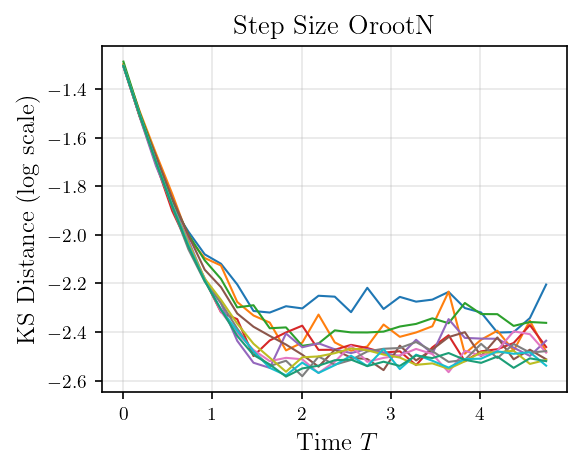

In [16]:
# PLOTTER for MC investigation.
dt_colours = list(plt.cm.tab10.colors) + list(plt.cm.Dark2.colors)
dt_choices = ["OrootN"]
M_colours = dt_colours
M_range = [100, 200, 300, 400, 500, 1000, 2000, 3000, 4000, 5000, 10000]

fig, axes = plt.subplots(figsize = (4, 3))
axes = [axes]
fixed_method = "implicit"

for ax, dt_choice in zip(axes, dt_choices):
    for j, M in enumerate(M_range):
        key = (M, dt_choice, method)
        data = mc_error_results[key]
        ax.plot(data["times"], np.log10(data["distances"]), label = M, color = M_colours[j], lw = 1) 

    ax.set_xlabel(r"Time $T$")
    ax.set_title(f"Step Size {dt_choice}")
    ax.grid(True, alpha = 0.3)

axes[0].set_ylabel("KS Distance (log scale)")

plt.show()

In [ ]:
payload = {}
for (M, dt_choice, method), data in mc_error_results.items():
    prefix = f"M{M}-dt{dt_choice}-{method}"
    payload[f"{prefix}_times"] = data["times"]
    payload[f"{prefix}_distances"] = data["distances"]
    payload[f"{prefix}_particles"] = data["particles"]
    payload["N"] = [30]
    payload["T"] = [5.0]
    
np.savez_compressed("data/mc_error-investigation-2.npz", **payload)

In [12]:
loaded_data = np.load("data/mc_error-investigation-2.npz")
mc_error_results = {}

for key in loaded_data.files:
    if key.endswith("_times"):
        prefix = key.replace("_times", "")
        parts = prefix.split("-")
        
        M = int(parts[0][1:])
        dt_choice = parts[1][2:]
        method = parts[2]
        
        mc_error_results[(M, dt_choice, method)] = {
            "times": loaded_data[f"{prefix}_times"],
            "distances": loaded_data[f"{prefix}_distances"],
            "particles": loaded_data[f"{prefix}_particles"]
        }

N = loaded_data["N"][0]
T = loaded_data["T"][0]

In [13]:
M_colours = dt_colours

fig, axes = plt.subplots(figsize = (4, 3))
axes = [axes]
fixed_method = "implicit"

for ax, dt_choice in zip(axes, dt_choices):
    for j, M in enumerate(M_range):
        key = (M, dt_choice, method)
        data = mc_error_results[key]
        ax.plot(data["times"], np.log10(data["distances"]), label = M, color = M_colours[j], lw = 1) 

    ax.set_xlabel(r"Time $T$")
    ax.set_title(f"Step Size {dt_choice}")
    ax.grid(True, alpha = 0.3)

axes[0].set_ylabel("KS Distance (log scale)")

plt.show()

NameError: name 'dt_colours' is not defined

---
---
---
---
---

10/06 Check for eigenvalue crossing.

Main idea: run sampler up to some fixed time e.g. $T = 0$, $T=1$, ..., and then take one step. See if the particles cross. Will need to be careful in the crossing (check that it is that step that forces them to cross?)

In [208]:
importlib.reload(sampler);
T = 5.0; M = 100; # NOTE Upgrade M later (to say 1000). Expect 30 minutes for 1000.
T_stars = [1.0]
N_range = [10, 30, 50, 100] 
c_range = [500, 200, 100, 50, 20, 10, 5, 2, 1, 0.1] # dt = c/N^2 for crossing.
methods = ["euler", "tamed"]

cross_results = {}
for N, method, T_star in itertools.product(N_range, methods, T_stars):
    clear_output(wait = True)
    print(rf"Checking crossings for N = {N} ({method}), T* = {T_star}.")

    dt_range = [c/(N**2) for c in c_range]
    dt = 1/N if method == "implicit" else 1/(N**2)
    num_crosses = sampler.stochastic_sampler(N, T, dt, method = method, num_trials = M, 
                                             track_crossing = True, T_star = T_star, cross_dts = dt_range)
    
    cross_results[(N, method, T_star)] = {"cs": c_range, "dts": dt_range, "crosses": num_crosses, "M": M}

Checking crossings for N = 100 (tamed), T* = 1.0.


In [209]:
import pickle
filename = f"data/cross_results_M100.pkl"

with open(filename, "wb") as f:
    pickle.dump(cross_results, f)

In [210]:
with open(filename, "rb") as f:
    cross_results_loaded = pickle.load(f)

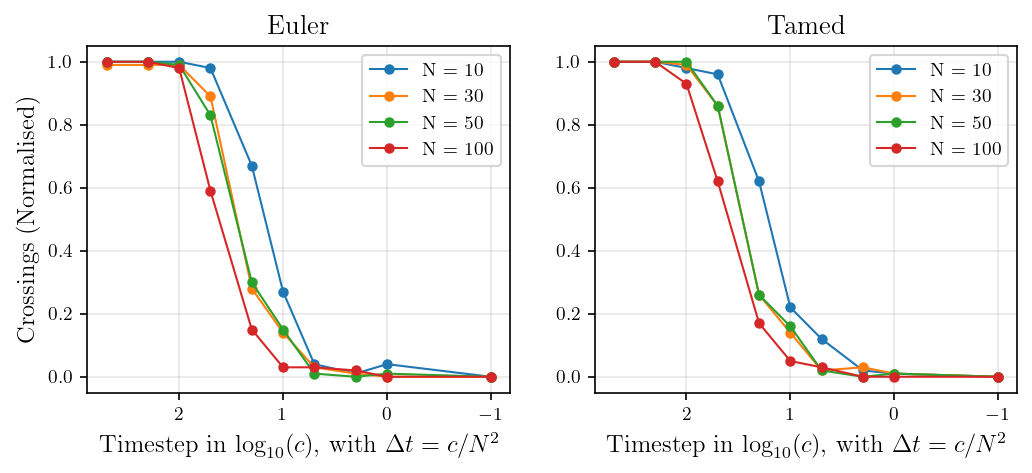

In [211]:
# CROSSINGS PLOTTER.
crossing_colours = list(plt.cm.tab10.colors) + list(plt.cm.Dark2.colors)
fig, axes = plt.subplots(1, 2, figsize = (8, 3))

fixed_Tstar = 1.0

for ax, method in zip(axes, methods):
    if (method == "implicit"):
        continue

    for j, N in enumerate(N_range):
        key = (N, method, fixed_Tstar)
        data = cross_results[key]

        ax.plot(np.log10(data["cs"]), data["crosses"] / data["M"], lw = 1, color = crossing_colours[j], label = f"N = {N}", marker = 'o')
        ax.xaxis.set_inverted(True)
    
    ax.set_title(method.capitalize())
    ax.set_xlabel("Timestep in $\log_{10}(c)$, with $\Delta t = c/N^2$")
    ax.grid(True, alpha = 0.3)
    ax.legend(loc = "upper right", fontsize = 9)

axes[0].set_ylabel(f"Crossings (Normalised)")

# c_range = [500, 100, 10, 1, 0.1, 0.01] 
plt.show()

Decide how to vary $\Delta t$. Currently have $c/N^2$ for a wide discrete range of $0.1 \leq c \leq 500$. 